In [1]:
# Import Libraries

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from openpyxl import Workbook
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter

In [2]:
# Project Directory Structure

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "tables"

MODELS_DIR = PROJECT_ROOT / "models"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
REPORT_DIR = PROJECT_ROOT / "report"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Tables directory: {TABLES_DIR}")

Project root: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business
Processed data directory: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\data\processed
Figures directory: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures
Tables directory: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables


In [3]:
# Plot Settings

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "normal",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    "font.size": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.alpha": 0.25,
    "grid.linestyle": "--"
})

In [4]:
# Project Colour Palette

PROJECT_COLOURS = {
    "primary": "#1f77b4",
    "secondary": "#ff7f0e",
    "success": "#2ca02c",
    "danger": "#d62728",
    "warning": "#bcbd22",
    "purple": "#9467bd",
    "grey": "#7f7f7f",
    "light_grey": "#d9d9d9",
    "dark": "#333333"
}

PROJECT_PALETTE = [
    PROJECT_COLOURS["primary"],
    PROJECT_COLOURS["secondary"],
    PROJECT_COLOURS["success"],
    PROJECT_COLOURS["danger"],
    PROJECT_COLOURS["purple"],
    PROJECT_COLOURS["warning"],
    PROJECT_COLOURS["grey"]
]

sns.set_palette(PROJECT_PALETTE)

In [5]:
# Figure-Saving Function

def save_figure(
    fig,
    number,
    filename,
    title=None,
    dpi=300,
    file_format="png"
):
    """
    Save a Matplotlib figure to the project's figures directory.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save.
    number : int
        Sequential figure number.
    filename : str
        Short descriptive filename without extension.
    title : str, optional
        Figure title used as the caption.
    dpi : int, default=300
        Output resolution.
    file_format : str, default="png"
        Output file format.
    """

    safe_filename = (
        filename.strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    output_path = (
        FIGURES_DIR /
        f"figure_{number:02d}_{safe_filename}.{file_format}"
    )

    # Add caption to the saved figure
    if title:
        fig.text(
            0.5,
            0.015,
            f"Figure {number}. {title}",
            ha="center",
            fontsize=11,
            style="italic"
        )

        fig.tight_layout(rect=[0, 0.05, 1, 1])

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"✓ Figure {number} saved")
    print(f"Location: {output_path}")

    return output_path

In [6]:
# Excel Table-Saving Function

def save_table_excel(
    dataframe,
    filename,
    caption,
    sheet_name="Table",
    decimal_places=2
):
    """
    Save a pandas DataFrame as a professionally formatted Excel table.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Table to export.
    filename : str
        Excel filename, including the .xlsx extension.
    caption : str
        Caption displayed above the table.
    sheet_name : str, default "Table"
        Worksheet name.
    decimal_places : int, default 2
        Number of decimal places applied to numeric cells.
    """

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe must be a pandas DataFrame.")

    if not filename.lower().endswith(".xlsx"):
        filename = f"{filename}.xlsx"

    output_path = TABLES_DIR / filename

    workbook = Workbook()
    worksheet = workbook.active
    worksheet.title = sheet_name[:31]

    # Styles
    
    caption_fill = PatternFill(
        fill_type="solid",
        fgColor="1F4E78"
    )

    header_fill = PatternFill(
        fill_type="solid",
        fgColor="D9EAF7"
    )

    caption_font = Font(
        bold=True,
        color="FFFFFF",
        size=12
    )

    header_font = Font(
        bold=True,
        color="000000"
    )

    thin_grey = Side(
        style="thin",
        color="B7B7B7"
    )

    cell_border = Border(
        left=thin_grey,
        right=thin_grey,
        top=thin_grey,
        bottom=thin_grey
    )

    # Caption

    total_columns = max(len(dataframe.columns), 1)

    worksheet.merge_cells(
        start_row=1,
        start_column=1,
        end_row=1,
        end_column=total_columns
    )

    caption_cell = worksheet.cell(row=1, column=1, value=caption)
    caption_cell.fill = caption_fill
    caption_cell.font = caption_font
    caption_cell.alignment = Alignment(
        horizontal="left",
        vertical="center"
    )

    worksheet.row_dimensions[1].height = 24

    # Leave row 2 blank.
    header_row = 3
    data_start_row = 4

    # Column headers
    
    for column_number, column_name in enumerate(
        dataframe.columns,
        start=1
    ):
        cell = worksheet.cell(
            row=header_row,
            column=column_number,
            value=str(column_name)
        )

        cell.fill = header_fill
        cell.font = header_font
        cell.border = cell_border
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    # Table data
    
    for row_number, row_values in enumerate(
        dataframe.itertuples(index=False, name=None),
        start=data_start_row
    ):
        for column_number, value in enumerate(row_values, start=1):

            # Convert NumPy data types to standard Python types.
            if isinstance(value, np.generic):
                value = value.item()

            # Replace pandas missing values with blank Excel cells.
            if pd.isna(value):
                value = None

            cell = worksheet.cell(
                row=row_number,
                column=column_number,
                value=value
            )

            cell.border = cell_border
            cell.alignment = Alignment(
                vertical="top",
                wrap_text=True
            )

            if isinstance(value, (int, float)) and not isinstance(value, bool):
                cell.number_format = (
                    "0"
                    if decimal_places == 0
                    else "0." + ("0" * decimal_places)
                )

    # Column widths
    
    for column_number, column_name in enumerate(
        dataframe.columns,
        start=1
    ):
        column_letter = get_column_letter(column_number)

        values = [str(column_name)]

        for value in dataframe.iloc[:, column_number - 1]:
            if not pd.isna(value):
                values.append(str(value))

        maximum_length = max(len(value) for value in values)

        worksheet.column_dimensions[column_letter].width = min(
            max(maximum_length + 2, 12),
            55
        )

    # Worksheet settings
  
    worksheet.freeze_panes = "A4"
    worksheet.auto_filter.ref = (
        f"A{header_row}:"
        f"{get_column_letter(total_columns)}"
        f"{header_row + len(dataframe)}"
    )

    worksheet.sheet_view.showGridLines = False

    workbook.save(output_path)

    print(f"Table saved: {caption}")
    print(f"Location: {output_path}")

    return output_path

In [7]:
# Chart-Formatting Function

def format_chart(
    ax,
    title,
    xlabel=None,
    ylabel=None,
    show_grid=True,
    grid_axis="y",
    rotate_x=False
):
    """
    Apply consistent project formatting to a Matplotlib chart.
    """

    ax.set_title(
        title,
        loc="left",
        pad=15,
        fontweight="bold"
    )

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if show_grid:
        ax.grid(
            visible=True,
            axis=grid_axis,
            linestyle="--",
            alpha=0.25
        )
    else:
        ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if rotate_x:
        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right"
        )

    return ax

In [8]:
# Axis-Formatting Functions

def format_currency_axis(ax, axis="y", decimals=0):
    """
    Format an axis as US dollars.
    """

    formatter = mtick.StrMethodFormatter(
        "${x:,.%df}" % decimals
    )

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        raise ValueError("axis must be either 'x' or 'y'.")

    return ax


def format_percentage_axis(ax, axis="y", decimals=0):
    """
    Format an axis whose values are already expressed from 0 to 100.
    """

    formatter = mtick.StrMethodFormatter(
        "{x:,.%df}%%" % decimals
    )

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        raise ValueError("axis must be either 'x' or 'y'.")

    return ax


def format_number_axis(ax, axis="y", decimals=0):
    """
    Add thousands separators to a numerical axis.
    """

    formatter = mtick.StrMethodFormatter(
        "{x:,.%df}" % decimals
    )

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        raise ValueError("axis must be either 'x' or 'y'.")

    return ax

In [9]:
# Bar-Label Function

def add_bar_labels(
    ax,
    decimals=0,
    prefix="",
    suffix="",
    padding=3
):
    """
    Add formatted value labels to vertical or horizontal bars.
    """

    for container in ax.containers:

        labels = []

        for bar in container:
            value = (
                bar.get_height()
                if bar.get_height() != 0
                else bar.get_width()
            )

            if pd.isna(value):
                labels.append("")
            else:
                labels.append(
                    f"{prefix}{value:,.{decimals}f}{suffix}"
                )

        ax.bar_label(
            container,
            labels=labels,
            padding=padding,
            fontsize=9
        )

    return ax

# Exploratory Data Analysis

The purpose of this notebook is to explore the cleaned Airbnb dataset and identify meaningful patterns, relationships and business insights. The analysis is structured around a series of business questions that investigate revenue, pricing strategies, occupancy, guest satisfaction and market characteristics. The findings will support the predictive modelling stage of the project.

## Business Questions

1. How is annual revenue distributed across Airbnb listings?
2. Which property characteristics are associated with higher annual revenue?
3. Do Airbnb Superhosts generate more revenue than non-Superhosts?
4. Does a higher average daily rate correspond to higher annual revenue?
5. Does a higher number of bookings correspond to higher annual revenue?
6. What factors are associated with higher occupancy rates?
7. Do higher guest ratings correspond to higher annual revenue?
8. Which guest rating dimensions are most strongly associated with annual revenue?

In [10]:
# Load Cleaned Dataset

airbnb = pd.read_csv(
    PROCESSED_DATA_DIR / "airbnb_cleaned.csv",
    parse_dates=["Created Date", "Last Scraped Date"]
)

print(f"Dataset loaded successfully: {airbnb.shape[0]:,} rows × {airbnb.shape[1]} columns")

airbnb.head()

Dataset loaded successfully: 145,825 rows × 50 columns


C:\Users\Probook\AppData\Local\Temp\ipykernel_11800\1407224894.py:3: DtypeWarning: Columns (0: Zipcode) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb = pd.read_csv(


,Listing Title,Property Type,Listing Type,Created Date,Last Scraped Date,Country,City,Zipcode,Number of Reviews,Bedrooms,...,Average Daily Rate (USD),Annual Revenue LTM (USD),State,Has Wifi,Has Kitchen,Has Parking,Has Pool,Has Air Conditioning,Has Washer,Listing Age (Days)
0,Spacious & Private Townhome | 5 mins drive to ...,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,1,3,...,145,3126,NaN,1,1,1,1,1,1,163.0
1,Spacious and Ornate 2BR Apartment in Dubai South,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,24,2,...,79,21815,NaN,1,1,1,1,1,1,163.0
2,Exceptional 2BR near Expo City Dubai!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,13,2,...,70,14717,NaN,1,1,1,1,1,1,163.0
3,Stylish Apartment Surrounded by Lush Green Parks!,Entire rental unit,entire_home,2023-07-31,2024-01-10,AE,Dubai,25314,12,2,...,192,41775,NaN,1,1,1,1,1,0,163.0
4,OFFER! 50% OFF! I am very cool and sleep 6!,Entire condo,entire_home,2023-07-31,2024-01-03,AE,Dubai,25314,10,2,...,74,4461,NaN,1,1,1,1,1,1,156.0


Business Question 1

How is annual revenue distributed across Airbnb listings?

In [15]:
# Annual Revenue Summary Statistics

revenue_summary = airbnb["Annual Revenue LTM (USD)"].describe().to_frame()

display(revenue_summary)

save_table_excel(
    dataframe=revenue_summary,
    filename="table_11_revenue_summary_statistics.xlsx",
    caption="Table 11. Summary Statistics for Annual Revenue",
    sheet_name="Revenue Summary",
    decimal_places=2
)

,Annual Revenue LTM (USD)
count,1.458250e+05
mean,1.795272e+04
std,2.588228e+04
min,2.000000e+00
25%,2.916000e+03
50%,9.150000e+03
75%,2.323400e+04
max,1.290235e+06


Table saved: Table 11. Summary Statistics for Annual Revenue
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_11_revenue_summary_statistics.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_11_revenue_summary_statistics.xlsx')

✓ Figure 8 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_08_annual_revenue_distribution.png


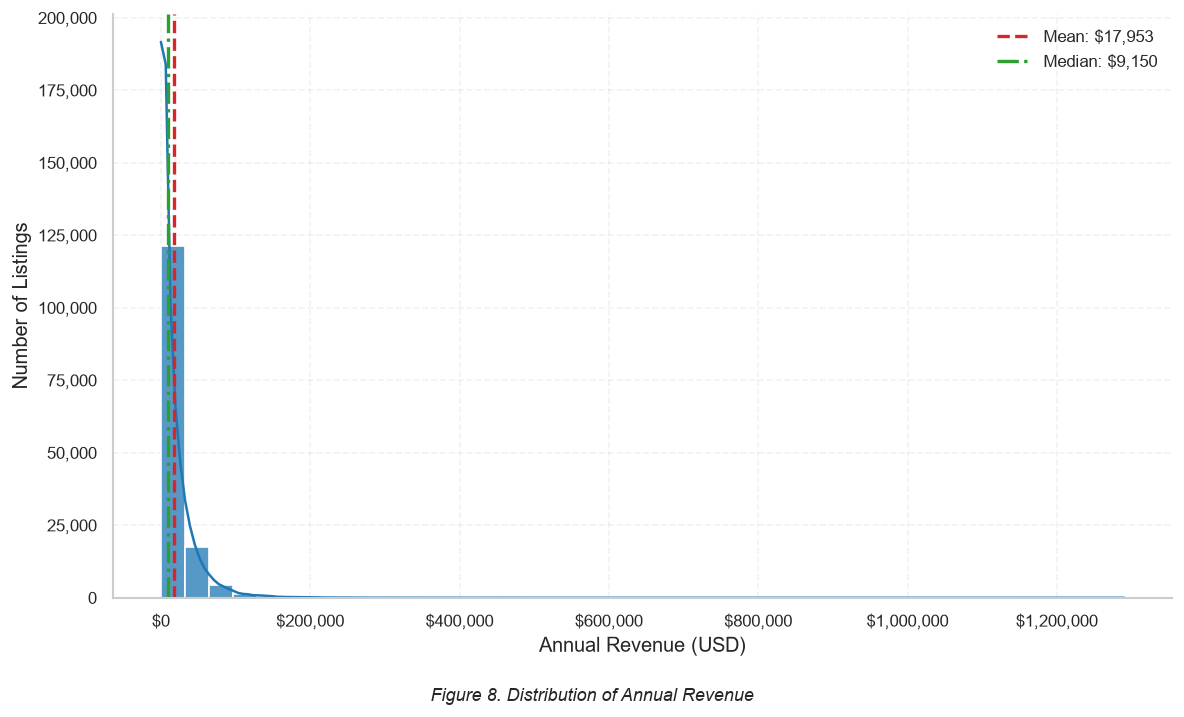

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=airbnb,
    x="Annual Revenue LTM (USD)",
    bins=40,
    kde=True,
    color=PROJECT_COLOURS["primary"],
    edgecolor="white",
    alpha=0.75,
    ax=ax
)

# Mean and median
mean_rev = airbnb["Annual Revenue LTM (USD)"].mean()
median_rev = airbnb["Annual Revenue LTM (USD)"].median()

ax.axvline(
    mean_rev,
    color=PROJECT_COLOURS["danger"],
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_rev:,.0f}"
)

ax.axvline(
    median_rev,
    color=PROJECT_COLOURS["success"],
    linestyle="-.",
    linewidth=2,
    label=f"Median: ${median_rev:,.0f}"
)

format_chart(
    ax,
    title=None,
    xlabel="Annual Revenue (USD)",
    ylabel="Number of Listings"
)

format_currency_axis(ax, axis="x")
format_number_axis(ax, axis="y")

ax.legend(frameon=False)

save_figure(
    fig,
    number=8,
    filename="annual_revenue_distribution",
    title="Distribution of Annual Revenue"
)

plt.show()

C:\Users\Probook\AppData\Local\Temp\ipykernel_11800\2582632367.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


✓ Figure 9 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_09_annual_revenue_boxplot.png


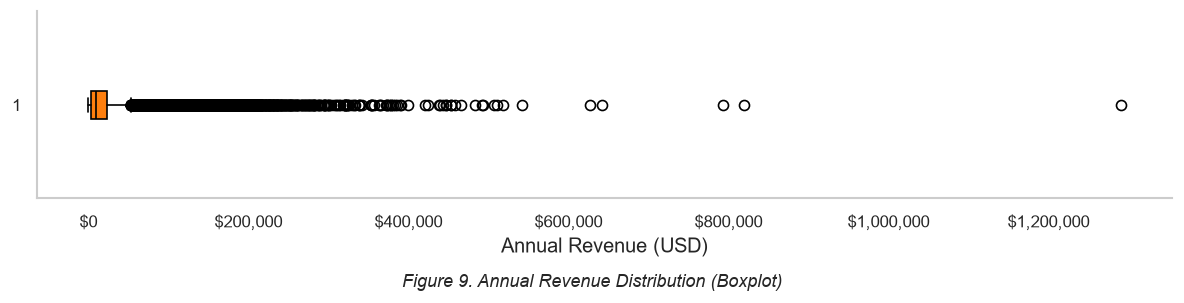

In [13]:
# Figure 8. Annual Revenue Boxplot

fig, ax = plt.subplots(figsize=(10, 2.5))

ax.boxplot(
    airbnb["Annual Revenue LTM (USD)"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=PROJECT_COLOURS["secondary"]),
    medianprops=dict(color="black")
)

format_chart(
    ax,
    title=None,
    xlabel="Annual Revenue (USD)",
    show_grid=False
)

format_currency_axis(ax, axis="x", decimals=0)

save_figure(
    fig,
    number=9,
    filename="annual_revenue_boxplot",
    title="Annual Revenue Distribution (Boxplot)"
)

plt.show()

The distribution of annual revenue is positively skewed, with the majority of Airbnb listings generating relatively modest annual revenue and a smaller proportion of listings achieving substantially higher earnings. The boxplot confirms the presence of numerous high-value observations, which were previously assessed as legitimate market variation rather than data quality issues. This suggests that revenue within the Airbnb market is unevenly distributed, reflecting differences in property characteristics, pricing strategies, occupancy levels and host performance.

Business Question 2

Which property characteristics are associated with higher annual revenue?

In [14]:
# Revenue by Property Type

property_summary = (
    airbnb
    .groupby("Property Type")
    .agg(
        Median_Revenue=("Annual Revenue LTM (USD)", "median"),
        Mean_Revenue=("Annual Revenue LTM (USD)", "mean"),
        Listings=("Property Type", "count")
    )
    .sort_values("Listings", ascending=False)
    .head(10)
    .sort_values("Median_Revenue", ascending=False)
)

property_summary

,Median_Revenue,Mean_Revenue,Listings
Property Type,,,
Entire home,18034.0,31451.902819,17133
Entire guest suite,15582.0,20690.795139,2592
Entire serviced apartment,12308.5,22682.402601,3460
Entire condo,12184.5,20819.708018,12672
Room in hotel,11008.5,16778.117459,2188
Entire rental unit,10086.0,17728.353598,56847
Private room in condo,6313.5,10501.805231,2906
Private room in townhouse,5454.0,10390.763510,2017
Private room in home,4287.0,7294.944040,13063


In [16]:
save_table_excel(
    dataframe=property_summary.round(2),
    filename="table_12_property_type_revenue.xlsx",
    caption="Table 12. Annual Revenue by Property Type",
    sheet_name="Property Type Revenue",
    decimal_places=2
)

Table saved: Table 12. Annual Revenue by Property Type
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_12_property_type_revenue.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_12_property_type_revenue.xlsx')

✓ Figure 10 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_10_property_type_revenue.png


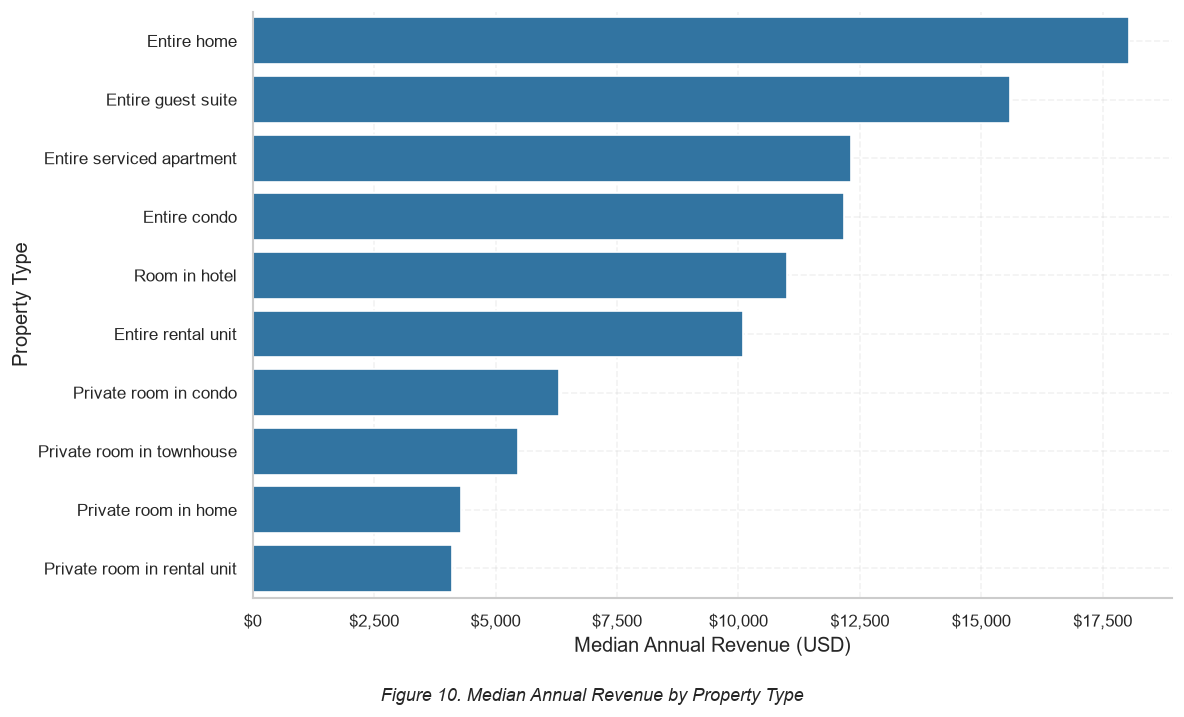

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=property_summary.reset_index(),
    x="Median_Revenue",
    y="Property Type",
    color=PROJECT_COLOURS["primary"],
    ax=ax
)

format_chart(
    ax,
    title=None,
    xlabel="Median Annual Revenue (USD)",
    ylabel="Property Type"
)

format_currency_axis(ax, axis="x")

save_figure(
    fig,
    number=10,
    filename="property_type_revenue",
    title="Median Annual Revenue by Property Type"
)

plt.show()

Property type is associated with notable differences in annual revenue. Among the ten most common property types, some generate considerably higher median annual revenue than others, suggesting that accommodation type influences earning potential. These differences may reflect variation in nightly pricing, occupancy levels, property size, and guest demand.

Business Question 3

Do Airbnb Superhosts generate more revenue than non-Superhosts?

In [18]:
# Select the variables required for the analysis
superhost_analysis = airbnb[
    ["Airbnb Superhost", "Annual Revenue LTM (USD)"]
].dropna().copy()

# Convert the original t/f values into readable labels
superhost_analysis["Superhost Status"] = (
    superhost_analysis["Airbnb Superhost"]
    .map({
        "t": "Superhost",
        "f": "Non-Superhost"
    })
)

# Confirm that the categories were mapped correctly
superhost_analysis["Superhost Status"].value_counts()

Superhost Status
Non-Superhost    99799
Superhost        46026
Name: count, dtype: int64

In [20]:
# Calculate summary statistics by Superhost status
superhost_summary = (
    superhost_analysis
    .groupby("Superhost Status")
    .agg(
        Median_Revenue=("Annual Revenue LTM (USD)", "median"),
        Mean_Revenue=("Annual Revenue LTM (USD)", "mean"),
        Listings=("Annual Revenue LTM (USD)", "count")
    )
    .reindex(["Non-Superhost", "Superhost"])
)

# Rename the columns for clearer presentation
superhost_summary_display = superhost_summary.rename(
    columns={
        "Median_Revenue": "Median Revenue (USD)",
        "Mean_Revenue": "Mean Revenue (USD)",
        "Listings": "Number of Listings"
    }
)

print("Table 13. Annual Revenue by Superhost Status")
display(superhost_summary_display.round(2))

Table 13. Annual Revenue by Superhost Status


,Median Revenue (USD),Mean Revenue (USD),Number of Listings
Superhost Status,,,
Non-Superhost,7069.0,14645.11,99799
Superhost,15380.5,25124.68,46026


In [21]:
save_table_excel(
    dataframe=superhost_summary_display.round(2),
    filename="table_13_superhost_revenue.xlsx",
    caption="Table 13. Annual Revenue by Superhost Status",
    sheet_name="Superhost Revenue",
    decimal_places=2
)

Table saved: Table 13. Annual Revenue by Superhost Status
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_13_superhost_revenue.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_13_superhost_revenue.xlsx')

✓ Figure 11 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_11_superhost_revenue_distribution.png


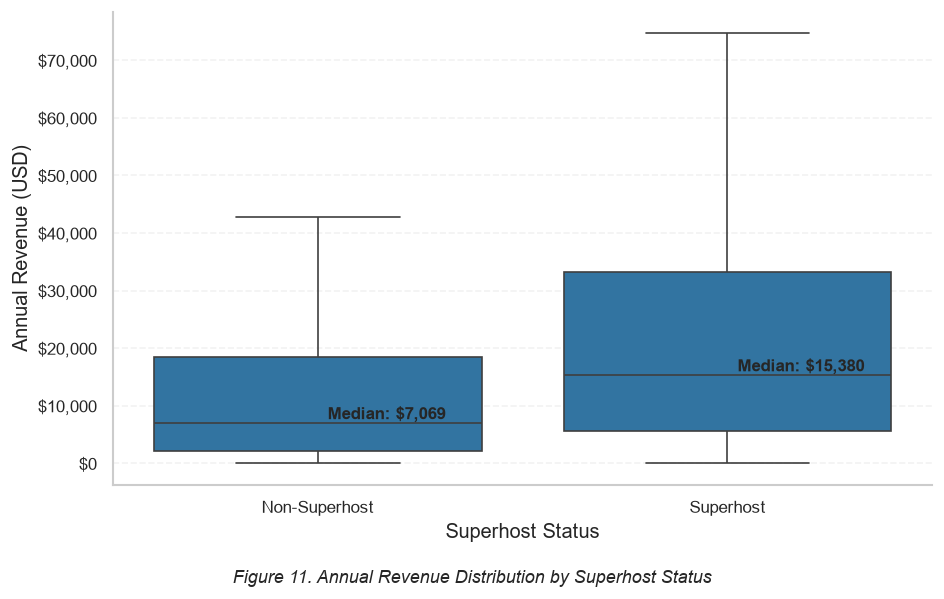

In [22]:
# Figure. Annual Revenue Distribution by Superhost Status

category_order = ["Non-Superhost", "Superhost"]

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=superhost_analysis,
    x="Superhost Status",
    y="Annual Revenue LTM (USD)",
    order=category_order,
    showfliers=False,
    ax=ax
)

format_chart(
    ax,
    title=None,
    xlabel="Superhost Status",
    ylabel="Annual Revenue (USD)"
)

format_currency_axis(
    ax,
    axis="y",
    decimals=0
)

# Add median labels above each box
for position, status in enumerate(category_order):
    median_value = superhost_summary.loc[status, "Median_Revenue"]

    ax.text(
        position,
        median_value,
        f"  Median: ${median_value:,.0f}",
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

save_figure(
    fig,
    number=11,
    filename="superhost_revenue_distribution",
    title="Annual Revenue Distribution by Superhost Status"
)

plt.show()

In [23]:
# Calculate the difference in median annual revenue

non_superhost_median = superhost_summary.loc[
    "Non-Superhost",
    "Median_Revenue"
]

superhost_median = superhost_summary.loc[
    "Superhost",
    "Median_Revenue"
]

median_difference = superhost_median - non_superhost_median

percentage_difference = (
    median_difference / non_superhost_median
) * 100

print(f"Non-Superhost median revenue: ${non_superhost_median:,.2f}")
print(f"Superhost median revenue: ${superhost_median:,.2f}")
print(f"Median revenue difference: ${median_difference:,.2f}")
print(f"Percentage difference: {percentage_difference:.1f}%")

Non-Superhost median revenue: $7,069.00
Superhost median revenue: $15,380.50
Median revenue difference: $8,311.50
Percentage difference: 117.6%


### Statistical Significance Test

Annual revenue was previously found to be strongly right-skewed. Therefore, the non-parametric Mann–Whitney U test was used to determine whether annual revenue differed significantly between Superhost and non-Superhost listings.

**H₀:** There is no significant difference in annual revenue between Superhost and non-Superhost listings.

**H₁:** There is a significant difference in annual revenue between Superhost and non-Superhost listings.

In [25]:
from scipy.stats import mannwhitneyu

# Create revenue groups
superhost_revenue = superhost_analysis.loc[
    superhost_analysis["Superhost Status"] == "Superhost",
    "Annual Revenue LTM (USD)"
]

non_superhost_revenue = superhost_analysis.loc[
    superhost_analysis["Superhost Status"] == "Non-Superhost",
    "Annual Revenue LTM (USD)"
]

# Mann–Whitney U test
u_statistic, p_value = mannwhitneyu(
    superhost_revenue,
    non_superhost_revenue,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {u_statistic:,.0f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the null hypothesis.")
    print("There is a statistically significant difference in annual revenue between Superhost and Non-Superhost listings.")
else:
    print("\nResult: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in annual revenue between Superhost and Non-Superhost listings.")

Mann–Whitney U statistic: 2,957,798,916
p-value: 0.000000

Result: Reject the null hypothesis.
There is a statistically significant difference in annual revenue between Superhost and Non-Superhost listings.


In [26]:
# Calculate rank-biserial correlation as an effect-size measure

n_superhost = len(superhost_revenue)
n_non_superhost = len(non_superhost_revenue)

rank_biserial = (
    (2 * u_statistic) /
    (n_superhost * n_non_superhost)
) - 1

absolute_effect = abs(rank_biserial)

if absolute_effect < 0.10:
    effect_interpretation = "negligible"
elif absolute_effect < 0.30:
    effect_interpretation = "small"
elif absolute_effect < 0.50:
    effect_interpretation = "moderate"
else:
    effect_interpretation = "large"

print(f"Rank-biserial correlation: {rank_biserial:.3f}")
print(f"Effect size interpretation: {effect_interpretation}")

Rank-biserial correlation: 0.288
Effect size interpretation: small


Superhost listings demonstrated substantially stronger financial performance than non-Superhost listings. The median annual revenue for Superhosts was $15,380.50, compared with $7,069.00 for non-Superhosts. This represents a median difference of $8,311.50, meaning that Superhost listings generated approximately 117.6% higher median annual revenue.

A Mann–Whitney U test showed that this difference was statistically significant (U = 2,957,798,916, p < 0.001). Therefore, the null hypothesis was rejected, indicating strong evidence that annual revenue differs between Superhost and non-Superhost listings.

The rank-biserial correlation was 0.288, indicating a small effect size. Although the difference is statistically significant, the effect size suggests that Superhost status alone explains only part of the variation in annual revenue. Other factors, such as property type, location, occupancy rate, pricing strategy and guest ratings, are also likely to contribute to listing performance. Consequently, Superhost status should be viewed as one of several indicators associated with higher revenue rather than the sole determinant of financial success.
Although the sample size was sufficiently large for a Welch's t-test to be robust under the Central Limit Theorem, annual revenue was highly right-skewed with substantial outliers. Therefore, the Mann–Whitney U test was selected because it makes fewer distributional assumptions and is more appropriate for comparing revenue distributions in this dataset.

Business Question 4

Does a higher average daily rate correspond to higher annual revenue?

In [27]:
# Select variables for analysis

adr_analysis = airbnb[
    ["Average Daily Rate (USD)", "Annual Revenue LTM (USD)"]
].dropna()

print(f"Listings included: {len(adr_analysis):,}")

adr_analysis.head()

Listings included: 145,825


,Average Daily Rate (USD),Annual Revenue LTM (USD)
0,145,3126
1,79,21815
2,70,14717
3,192,41775
4,74,4461


In [29]:
adr_summary = (
    adr_analysis[
        ["Average Daily Rate (USD)", "Annual Revenue LTM (USD)"]
    ]
    .describe()
    .T[
        ["count", "mean", "std", "min", "50%", "max"]
    ]
)

adr_summary.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Standard Deviation",
    "min": "Minimum",
    "50%": "Median",
    "max": "Maximum"
}, inplace=True)

print("Table 14. Summary Statistics for ADR and Annual Revenue")

display(adr_summary.round(2))

Table 14. Summary Statistics for ADR and Annual Revenue


,Count,Mean,Standard Deviation,Minimum,Median,Maximum
Average Daily Rate (USD),145825.0,198.69,238.65,1.0,143.0,33553.0
Annual Revenue LTM (USD),145825.0,17952.72,25882.28,2.0,9150.0,1290235.0


In [30]:
save_table_excel(
    dataframe=adr_summary.round(2),
    filename="table_14_adr_summary.xlsx",
    caption="Table 14. Summary Statistics for Average Daily Rate and Annual Revenue",
    sheet_name="ADR Summary",
    decimal_places=2
)

Table saved: Table 14. Summary Statistics for Average Daily Rate and Annual Revenue
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_14_adr_summary.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_14_adr_summary.xlsx')

In [31]:
airbnb["Average Daily Rate (USD)"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count    145825.000000
mean        198.687050
std         238.648368
min           1.000000
90%         377.000000
95%         521.000000
99%        1010.000000
99.5%      1333.880000
99.9%      2477.816000
max       33553.000000
Name: Average Daily Rate (USD), dtype: float64

✓ Figure 12 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_12_adr_vs_revenue.png


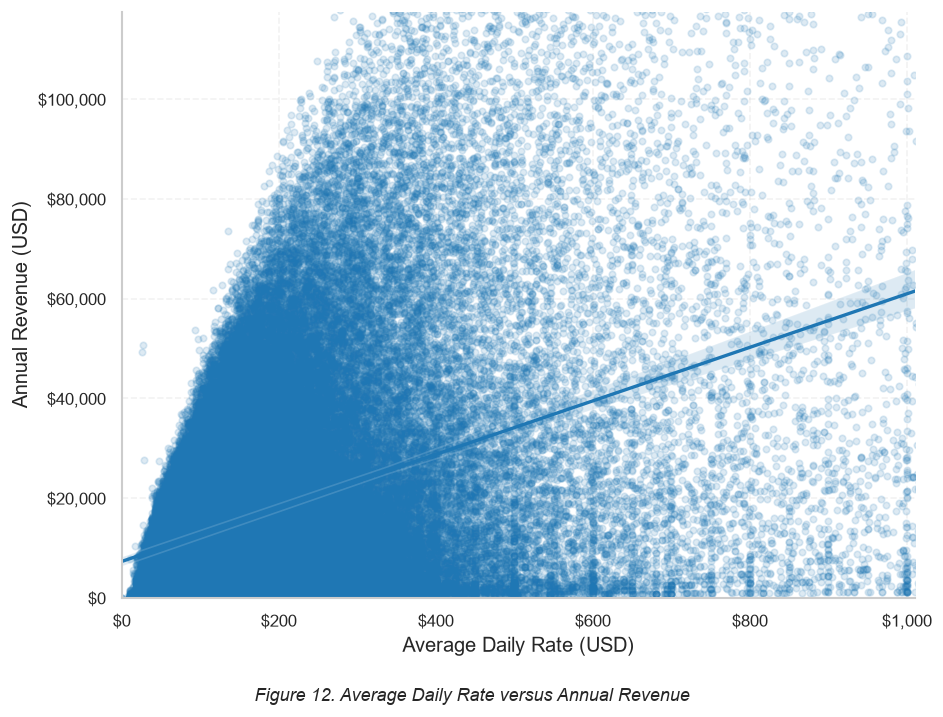

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=adr_analysis,
    x="Average Daily Rate (USD)",
    y="Annual Revenue LTM (USD)",
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"linewidth": 2},
    ax=ax
)

# Zoom to the central 99% of observations
ax.set_xlim(0, adr_analysis["Average Daily Rate (USD)"].quantile(0.99))
ax.set_ylim(0, adr_analysis["Annual Revenue LTM (USD)"].quantile(0.99))

format_chart(
    ax,
    title=None,
    xlabel="Average Daily Rate (USD)",
    ylabel="Annual Revenue (USD)"
)

format_currency_axis(ax, axis="x", decimals=0)
format_currency_axis(ax, axis="y", decimals=0)

save_figure(
    fig,
    number=12,
    filename="adr_vs_revenue",
    title="Average Daily Rate versus Annual Revenue"
)

plt.show()

In [33]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation
pearson_r, pearson_p = pearsonr(
    adr_analysis["Average Daily Rate (USD)"],
    adr_analysis["Annual Revenue LTM (USD)"]
)

# Spearman correlation
spearman_rho, spearman_p = spearmanr(
    adr_analysis["Average Daily Rate (USD)"],
    adr_analysis["Annual Revenue LTM (USD)"]
)

print("Correlation Analysis")
print("-" * 40)
print(f"Pearson's r     : {pearson_r:.3f} (p = {pearson_p:.6g})")
print(f"Spearman's rho  : {spearman_rho:.3f} (p = {spearman_p:.6g})")

Correlation Analysis
----------------------------------------
Pearson's r     : 0.495 (p = 0)
Spearman's rho  : 0.465 (p = 0)


In [34]:
from scipy.stats import linregress

result = linregress(
    adr_analysis["Average Daily Rate (USD)"],
    adr_analysis["Annual Revenue LTM (USD)"]
)

print(f"Slope: {result.slope:.2f}")
print(f"Intercept: {result.intercept:.2f}")
print(f"R²: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.6g}")

Slope: 53.68
Intercept: 7286.46
R²: 0.245
p-value: 0


Pearson's correlation analysis identified a moderate positive relationship between Average Daily Rate (ADR) and annual revenue (r = 0.495, p < 0.001), indicating that listings charging higher nightly rates generally achieved higher annual revenue. Spearman's rank correlation produced a similar result (ρ = 0.465, p < 0.001), suggesting that the observed association is robust despite the skewed distribution of annual revenue.

A simple linear regression further indicated that each additional $1 increase in ADR was associated with an estimated $53.68 increase in annual revenue, on average. The model explained approximately 24.5% of the variation in annual revenue (R² = 0.245), indicating that pricing is an important contributor to financial performance but is not the sole determinant. Other factors, including occupancy rate, property characteristics, Superhost status, and guest ratings, are also likely to influence annual revenue.

For visual clarity, Figure 11 displays the central 99% of observations. All listings, including extreme values, were retained in the correlation and regression analyses.

Business Question 5

Does a higher occupancy rate correspond to higher annual revenue?

In [35]:
occupancy_analysis = airbnb[
    ["Occupancy Rate LTM", "Annual Revenue LTM (USD)"]
].dropna()

print(f"Listings included: {len(occupancy_analysis):,}")

occupancy_analysis.head()

Listings included: 145,825


,Occupancy Rate LTM,Annual Revenue LTM (USD)
0,77,3126
1,78,21815
2,96,14717
3,86,41775
4,44,4461


In [36]:
occupancy_summary = (
    occupancy_analysis[
        ["Occupancy Rate LTM", "Annual Revenue LTM (USD)"]
    ]
    .describe()
    .T[
        ["count", "mean", "std", "min", "50%", "max"]
    ]
)

occupancy_summary.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Standard Deviation",
    "min": "Minimum",
    "50%": "Median",
    "max": "Maximum"
}, inplace=True)

print("Table 15. Summary Statistics for Occupancy Rate and Annual Revenue")

display(occupancy_summary.round(2))

Table 15. Summary Statistics for Occupancy Rate and Annual Revenue


,Count,Mean,Standard Deviation,Minimum,Median,Maximum
Occupancy Rate LTM,145825.0,67.05,26.72,1.0,70.0,100.0
Annual Revenue LTM (USD),145825.0,17952.72,25882.28,2.0,9150.0,1290235.0


In [37]:
save_table_excel(
    dataframe=occupancy_summary.round(2),
    filename="table_15_occupancy_summary.xlsx",
    caption="Table 15. Summary Statistics for Occupancy Rate and Annual Revenue",
    sheet_name="Occupancy Summary",
    decimal_places=2
)

Table saved: Table 15. Summary Statistics for Occupancy Rate and Annual Revenue
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_15_occupancy_summary.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_15_occupancy_summary.xlsx')

✓ Figure 13 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_13_occupancy_vs_revenue.png


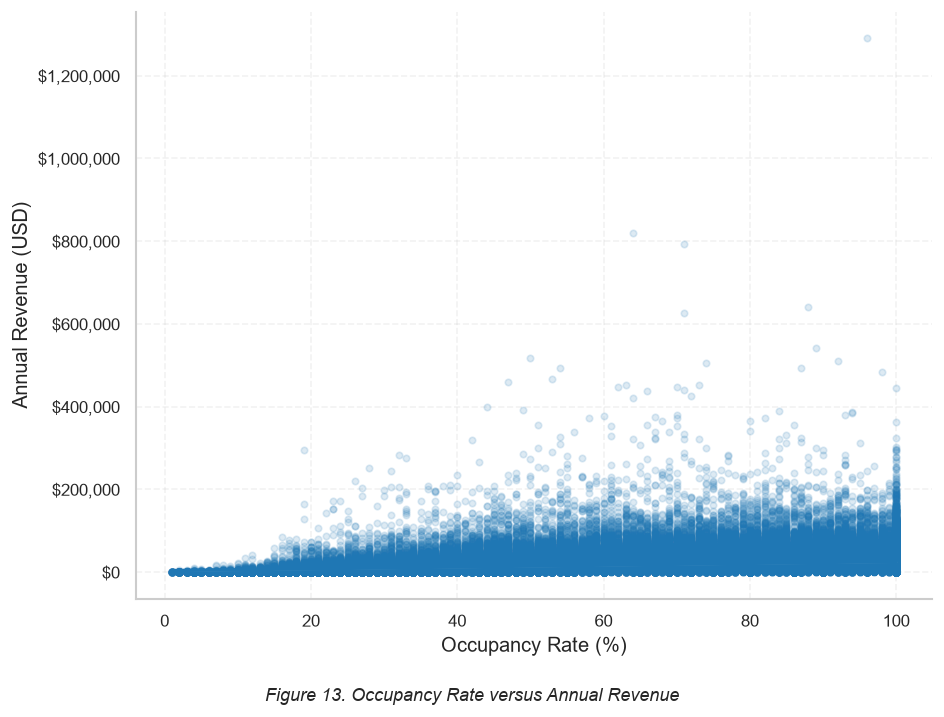

In [38]:
fig, ax = plt.subplots(figsize=(8,6))

sns.regplot(
    data=occupancy_analysis,
    x="Occupancy Rate LTM",
    y="Annual Revenue LTM (USD)",
    scatter_kws={"alpha":0.15, "s":15},
    line_kws={"linewidth":2},
    ax=ax
)

format_chart(
    ax,
    title=None,
    xlabel="Occupancy Rate (%)",
    ylabel="Annual Revenue (USD)"
)

format_currency_axis(ax, axis="y", decimals=0)

save_figure(
    fig,
    number=13,
    filename="occupancy_vs_revenue",
    title="Occupancy Rate versus Annual Revenue"
)

plt.show()

In [39]:
pearson_r, pearson_p = pearsonr(
    occupancy_analysis["Occupancy Rate LTM"],
    occupancy_analysis["Annual Revenue LTM (USD)"]
)

spearman_rho, spearman_p = spearmanr(
    occupancy_analysis["Occupancy Rate LTM"],
    occupancy_analysis["Annual Revenue LTM (USD)"]
)

print(f"Pearson's r: {pearson_r:.3f}")
print(f"Pearson p-value: {pearson_p:.6g}")

print(f"Spearman's rho: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.6g}")

Pearson's r: 0.226
Pearson p-value: 0
Spearman's rho: 0.356
Spearman p-value: 0


In [40]:
result = linregress(
    occupancy_analysis["Occupancy Rate LTM"],
    occupancy_analysis["Annual Revenue LTM (USD)"]
)

print(f"Slope: {result.slope:.2f}")
print(f"Intercept: {result.intercept:.2f}")
print(f"R²: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.6g}")

Slope: 218.90
Intercept: 3275.33
R²: 0.051
p-value: 0


Pearson's correlation analysis identified a weak positive linear relationship between occupancy rate and annual revenue (r = 0.226, p < 0.001), indicating that listings with higher occupancy rates generally achieved higher annual revenue. Spearman's rank correlation produced a somewhat stronger coefficient (ρ = 0.356, p < 0.001), suggesting that the relationship is positive but not strictly linear.

A simple linear regression indicated that each additional 1 percentage point increase in occupancy rate was associated with an estimated $218.90 increase in annual revenue, on average. However, the model explained only 5.1% of the variation in annual revenue (R² = 0.051), indicating that occupancy rate alone is a relatively weak predictor of financial performance.

Compared with the previous analysis of Average Daily Rate (ADR), occupancy exhibited a weaker relationship with annual revenue. This suggests that while maintaining high occupancy is beneficial, pricing strategy appears to have a stronger association with annual revenue than occupancy alone in this dataset.

Business Question 6

Does a higher number of bookings correspond to higher annual revenue?

In [41]:
bookings_analysis = airbnb[
    ["Number of Bookings LTM", "Annual Revenue LTM (USD)"]
].dropna()

print(f"Listings included: {len(bookings_analysis):,}")

bookings_analysis.head()

Listings included: 145,825


,Number of Bookings LTM,Annual Revenue LTM (USD)
0,9,3126
1,24,21815
2,14,14717
3,9,41775
4,6,4461


In [42]:
bookings_summary = (
    bookings_analysis[
        ["Number of Bookings LTM", "Annual Revenue LTM (USD)"]
    ]
    .describe()
    .T[
        ["count", "mean", "std", "min", "50%", "max"]
    ]
)

bookings_summary.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Standard Deviation",
    "min": "Minimum",
    "50%": "Median",
    "max": "Maximum"
}, inplace=True)

print("Table 16. Summary Statistics for Number of Bookings and Annual Revenue")

display(bookings_summary.round(2))

Table 16. Summary Statistics for Number of Bookings and Annual Revenue


,Count,Mean,Standard Deviation,Minimum,Median,Maximum
Number of Bookings LTM,145825.0,16.13,23.94,0.0,6.0,251.0
Annual Revenue LTM (USD),145825.0,17952.72,25882.28,2.0,9150.0,1290235.0


In [43]:
save_table_excel(
    dataframe=bookings_summary.round(2),
    filename="table_16_bookings_summary.xlsx",
    caption="Table 16. Summary Statistics for Number of Bookings and Annual Revenue",
    sheet_name="Bookings Summary",
    decimal_places=2
)

Table saved: Table 16. Summary Statistics for Number of Bookings and Annual Revenue
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_16_bookings_summary.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_16_bookings_summary.xlsx')

✓ Figure 14 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_14_bookings_vs_revenue.png


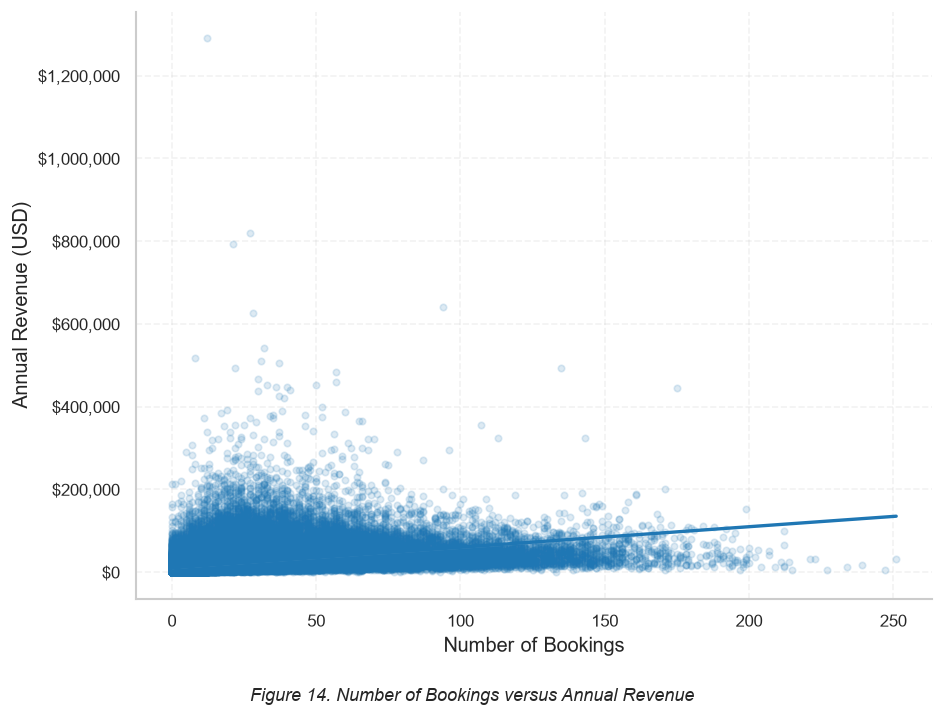

In [44]:
fig, ax = plt.subplots(figsize=(8,6))

sns.regplot(
    data=bookings_analysis,
    x="Number of Bookings LTM",
    y="Annual Revenue LTM (USD)",
    scatter_kws={"alpha":0.15, "s":15},
    line_kws={"linewidth":2},
    ax=ax
)

format_chart(
    ax,
    title=None,
    xlabel="Number of Bookings",
    ylabel="Annual Revenue (USD)"
)

format_currency_axis(ax, axis="y", decimals=0)

save_figure(
    fig,
    number=14,
    filename="bookings_vs_revenue",
    title="Number of Bookings versus Annual Revenue"
)

plt.show()

In [45]:
pearson_r, pearson_p = pearsonr(
    bookings_analysis["Number of Bookings LTM"],
    bookings_analysis["Annual Revenue LTM (USD)"]
)

spearman_rho, spearman_p = spearmanr(
    bookings_analysis["Number of Bookings LTM"],
    bookings_analysis["Annual Revenue LTM (USD)"]
)

print(f"Pearson's r: {pearson_r:.3f}")
print(f"Pearson p-value: {pearson_p:.6g}")

print(f"Spearman's rho: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.6g}")

Pearson's r: 0.460
Pearson p-value: 0
Spearman's rho: 0.724
Spearman p-value: 0


In [46]:
result = linregress(
    bookings_analysis["Number of Bookings LTM"],
    bookings_analysis["Annual Revenue LTM (USD)"]
)

print(f"Slope: {result.slope:.2f}")
print(f"Intercept: {result.intercept:.2f}")
print(f"R²: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.6g}")

Slope: 497.49
Intercept: 9926.57
R²: 0.212
p-value: 0


Pearson's correlation analysis identified a moderate positive linear relationship between the number of bookings and annual revenue (r = 0.460, p < 0.001), indicating that listings with more bookings generally achieved higher annual revenue. Spearman's rank correlation produced a substantially stronger coefficient (ρ = 0.724, p < 0.001), suggesting a strong positive monotonic relationship despite departures from linearity.

A simple linear regression indicated that each additional booking was associated with an estimated $497.49 increase in annual revenue, on average. The model explained approximately 21.2% of the variation in annual revenue (R² = 0.212), indicating that booking volume is an important contributor to revenue, although additional factors also influence financial performance.

Compared with occupancy rate, the number of bookings exhibited a much stronger relationship with annual revenue. Its explanatory power was also comparable to that of Average Daily Rate, suggesting that both pricing strategy and booking volume are key factors associated with Airbnb revenue performance.

Business Question 7

Do higher guest ratings correspond to higher annual revenue?

In [47]:
ratings_analysis = airbnb[
    ["Overall Rating", "Annual Revenue LTM (USD)"]
].dropna()

print(f"Listings included: {len(ratings_analysis):,}")

ratings_analysis.head()

Listings included: 124,974


,Overall Rating,Annual Revenue LTM (USD)
0,5.0,3126
1,4.2,21815
2,4.3,14717
3,4.4,41775
4,5.0,4461


In [48]:
ratings_summary = (
    ratings_analysis[
        ["Overall Rating", "Annual Revenue LTM (USD)"]
    ]
    .describe()
    .T[
        ["count", "mean", "std", "min", "50%", "max"]
    ]
)

ratings_summary.rename(columns={
    "count":"Count",
    "mean":"Mean",
    "std":"Standard Deviation",
    "min":"Minimum",
    "50%":"Median",
    "max":"Maximum"
}, inplace=True)

print("Table 17. Summary Statistics for Overall Rating and Annual Revenue")

display(ratings_summary.round(2))

Table 17. Summary Statistics for Overall Rating and Annual Revenue


,Count,Mean,Standard Deviation,Minimum,Median,Maximum
Overall Rating,124974.0,4.69,0.47,0.0,4.8,5.0
Annual Revenue LTM (USD),124974.0,19838.77,27139.63,8.0,10980.0,1290235.0


In [49]:
save_table_excel(
    dataframe=ratings_summary.round(2),
    filename="table_17_ratings_summary.xlsx",
    caption="Table 17. Summary Statistics for Overall Rating and Annual Revenue",
    sheet_name="Ratings Summary",
    decimal_places=2
)

Table saved: Table 17. Summary Statistics for Overall Rating and Annual Revenue
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\tables\table_17_ratings_summary.xlsx


WindowsPath('c:/Users/Probook/NCIRL 2025-2026/DA for Business/CA_DA for Business/tables/table_17_ratings_summary.xlsx')

✓ Figure 15 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_15_ratings_vs_revenue.png


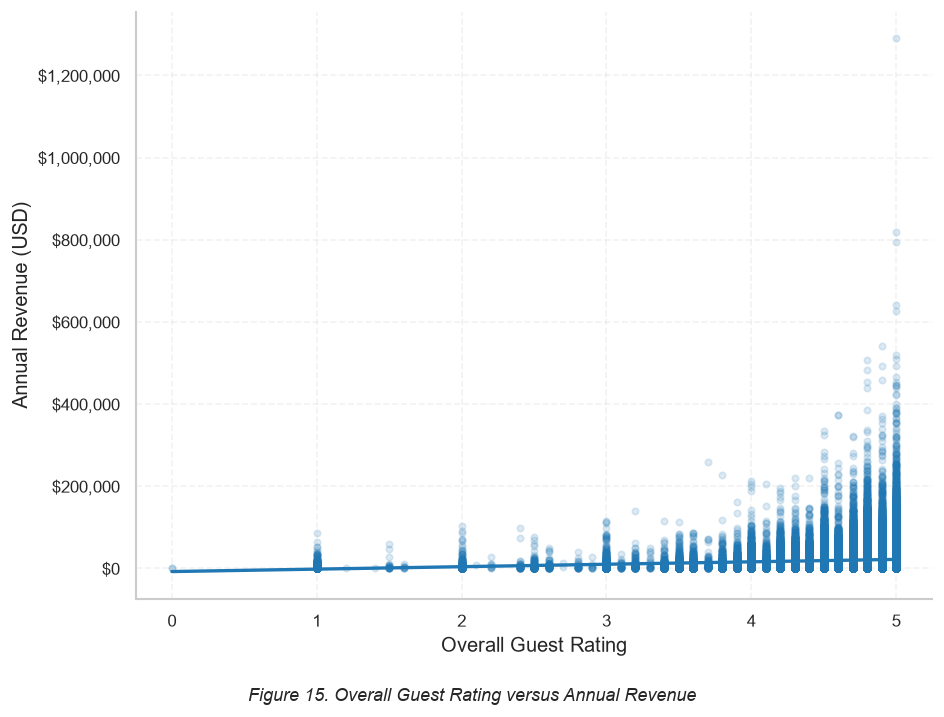

In [50]:
fig, ax = plt.subplots(figsize=(8,6))

sns.regplot(
    data=ratings_analysis,
    x="Overall Rating",
    y="Annual Revenue LTM (USD)",
    scatter_kws={"alpha":0.15, "s":15},
    line_kws={"linewidth":2},
    ax=ax
)

format_chart(
    ax,
    title=None,
    xlabel="Overall Guest Rating",
    ylabel="Annual Revenue (USD)"
)

format_currency_axis(ax, axis="y", decimals=0)

save_figure(
    fig,
    number=15,
    filename="ratings_vs_revenue",
    title="Overall Guest Rating versus Annual Revenue"
)

plt.show()

In [51]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    ratings_analysis["Overall Rating"],
    ratings_analysis["Annual Revenue LTM (USD)"]
)

spearman_rho, spearman_p = spearmanr(
    ratings_analysis["Overall Rating"],
    ratings_analysis["Annual Revenue LTM (USD)"]
)

print(f"Pearson's r: {pearson_r:.3f}")
print(f"Pearson p-value: {pearson_p:.6g}")

print(f"Spearman's rho: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.6g}")

Pearson's r: 0.102
Pearson p-value: 1.94606e-285
Spearman's rho: 0.043
Spearman p-value: 9.7328e-52


In [52]:
from scipy.stats import linregress

result = linregress(
    ratings_analysis["Overall Rating"],
    ratings_analysis["Annual Revenue LTM (USD)"]
)

print(f"Slope: {result.slope:.2f}")
print(f"Intercept: {result.intercept:.2f}")
print(f"R²: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.6g}")

Slope: 5922.15
Intercept: -7954.30
R²: 0.010
p-value: 1.94606e-285


Pearson's correlation analysis identified a very weak positive linear relationship between overall guest ratings and annual revenue (r = 0.102, p < 0.001). Spearman's rank correlation indicated an even weaker monotonic relationship (ρ = 0.043, p < 0.001), suggesting that higher guest ratings are only minimally associated with higher annual revenue.

A simple linear regression estimated that a one-point increase in overall guest rating was associated with approximately $5,922.15 higher annual revenue, on average. However, the model explained only 1.0% of the variation in annual revenue (R² = 0.010), indicating that overall guest ratings alone are a poor predictor of financial performance.

Compared with Average Daily Rate, occupancy rate, and the number of bookings, overall guest ratings exhibited the weakest association with annual revenue. This suggests that operational factors, particularly pricing strategy and booking volume, have a substantially stronger relationship with revenue than overall guest ratings in this dataset.

Business Question 8

Which guest rating dimensions are most strongly associated with annual revenue?

In [53]:
rating_dimensions = [
    "Airbnb Cleanliness Rating",
    "Airbnb Communication Rating",
    "Airbnb Checkin Rating",
    "Airbnb Accuracy Rating",
    "Airbnb Location Rating",
    "Airbnb Value Rating"
]

dimension_analysis = airbnb[
    rating_dimensions + ["Annual Revenue LTM (USD)"]
].dropna()

print(f"Listings included: {len(dimension_analysis):,}")

Listings included: 124,169


In [54]:
results = []

for variable in rating_dimensions:

    pearson_r, pearson_p = pearsonr(
        dimension_analysis[variable],
        dimension_analysis["Annual Revenue LTM (USD)"]
    )

    spearman_rho, spearman_p = spearmanr(
        dimension_analysis[variable],
        dimension_analysis["Annual Revenue LTM (USD)"]
    )

    results.append({
        "Rating Dimension": variable.replace("Airbnb ", "").replace(" Rating", ""),
        "Pearson's r": round(pearson_r, 3),
        "Spearman's ρ": round(spearman_rho, 3),
        "p-value": "<0.001"
    })

correlation_table = (
    pd.DataFrame(results)
      .sort_values("Pearson's r", ascending=False)
      .reset_index(drop=True)
)

correlation_table

,Rating Dimension,Pearson's r,Spearman's ρ,p-value
0,Location,0.118,0.105,<0.001
1,Cleanliness,0.104,0.093,<0.001
2,Accuracy,0.090,0.074,<0.001
3,Communication,0.080,0.071,<0.001
4,Checkin,0.071,0.051,<0.001
5,Value,0.060,0.013,<0.001


Pearson's correlation analysis showed that all six guest rating dimensions exhibited very weak positive relationships with annual revenue. Among the individual dimensions, Location demonstrated the strongest association (r = 0.118), followed by Cleanliness (r = 0.104) and Accuracy (r = 0.090). Communication, Check-in, and Value showed progressively weaker relationships.

Spearman's rank correlations produced similar results, confirming that none of the guest rating dimensions displayed a strong monotonic association with annual revenue. Although all correlations were statistically significant (p < 0.001), their magnitudes remained small, indicating limited practical significance.

Overall, these findings suggest that while higher guest ratings may be associated with slightly higher annual revenue, customer satisfaction measures alone are weak indicators of financial performance. Compared with operational factors such as Average Daily Rate, booking volume, occupancy rate, and Superhost status, guest rating dimensions have substantially less influence on revenue variation in this dataset.

✓ Figure 16 saved
Location: c:\Users\Probook\NCIRL 2025-2026\DA for Business\CA_DA for Business\figures\figure_16_correlation_matrix.png


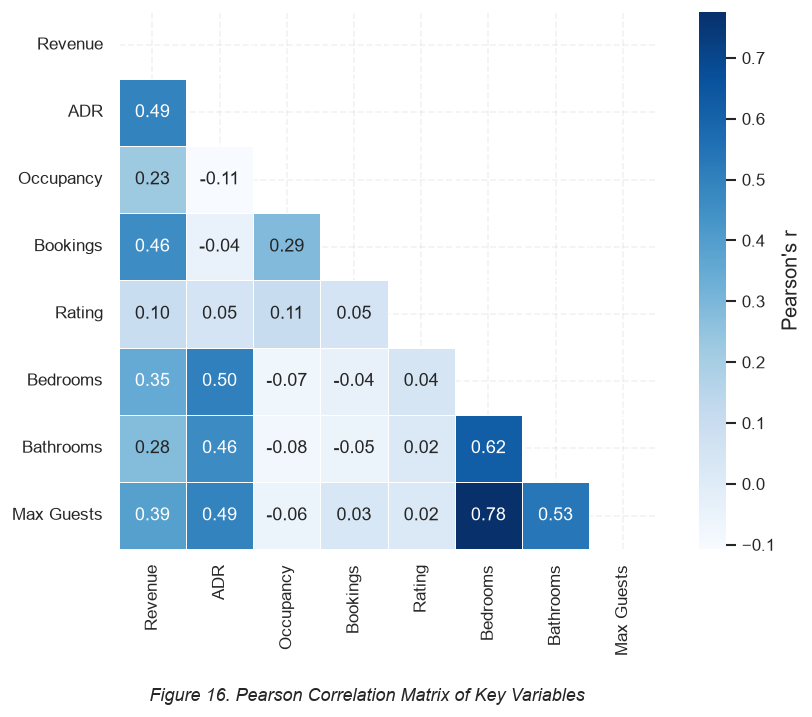

In [55]:
import numpy as np

corr_vars = [
    "Annual Revenue LTM (USD)",
    "Average Daily Rate (USD)",
    "Occupancy Rate LTM",
    "Number of Bookings LTM",
    "Overall Rating",
    "Bedrooms",
    "Bathrooms",
    "Max Guests"
]

corr = airbnb[corr_vars].corr(method="pearson")

label_map = {
    "Annual Revenue LTM (USD)": "Revenue",
    "Average Daily Rate (USD)": "ADR",
    "Occupancy Rate LTM": "Occupancy",
    "Number of Bookings LTM": "Bookings",
    "Overall Rating": "Rating",
    "Bedrooms": "Bedrooms",
    "Bathrooms": "Bathrooms",
    "Max Guests": "Max Guests"
}

corr = corr.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson's r"},
    ax=ax
)

format_chart(
    ax,
    title=None,
    xlabel="",
    ylabel=""
)

save_figure(
    fig,
    number=16,
    filename="correlation_matrix",
    title="Pearson Correlation Matrix of Key Variables"
)

plt.show()

Figure 16 provides a consolidated overview of the relationships among the principal numerical variables examined in this exploratory analysis. Average Daily Rate and Number of Bookings exhibited the strongest positive correlations with annual revenue, whereas Overall Rating showed only a weak association. Property characteristics such as Bedrooms, Bathrooms, and Max Guests displayed moderate intercorrelations but comparatively weaker relationships with revenue. These findings support the earlier analyses and identify pricing and booking activity as the strongest drivers of revenue within the dataset.

Overall, the exploratory data analysis identified several factors associated with annual Airbnb revenue. Average Daily Rate and the number of bookings demonstrated the strongest positive relationships with revenue, followed by occupancy rate and Superhost status. In contrast, overall guest ratings and individual rating dimensions exhibited only weak associations with revenue despite their statistical significance. These findings suggest that operational and pricing-related factors play a substantially greater role in explaining revenue variation than customer satisfaction metrics within this dataset. The insights obtained from the exploratory analysis provide a foundation for the predictive modelling undertaken in the subsequent notebook.